
Missing values:
Age                     0
MonthlyIncome           0
YearsWithCompany        0
ContractType            0
UsageHours              0
CustomerSatisfaction    0
NumComplaints           0
NumProducts             0
LoyaltyScore            0
LastActivityDays        0
Retention               0
dtype: int64


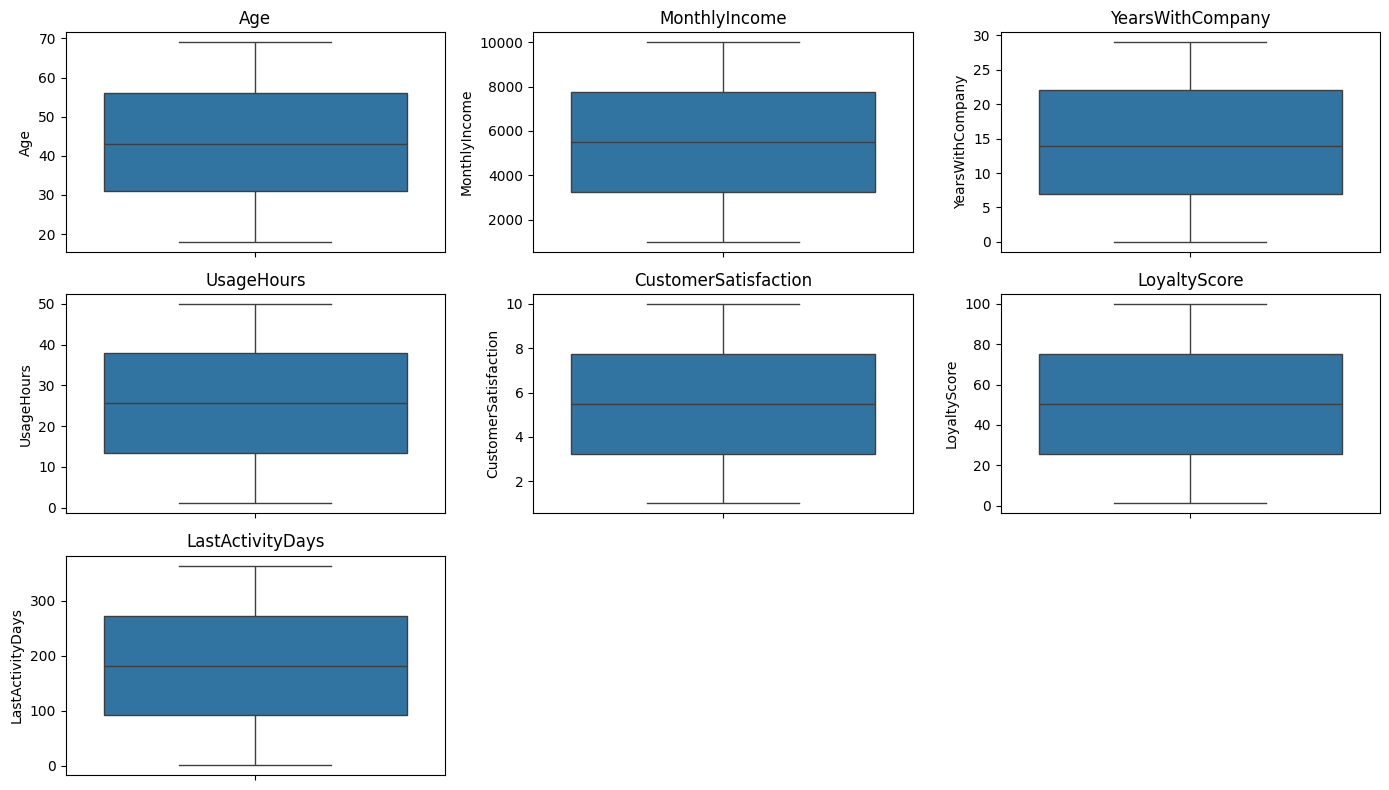


Final shapes:
X_train: (40000, 10)
X_test: (10000, 10)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# -------------------------------
# 1. Load data
# -------------------------------
data = pd.read_csv("Customer Retention Dataset.csv")

# -------------------------------
# 2. Column setup
# -------------------------------
target = "Retention"

num_cols = [
    'Age', 'MonthlyIncome', 'YearsWithCompany', 'UsageHours',
    'CustomerSatisfaction', 'LoyaltyScore', 'LastActivityDays'
]



# -------------------------------
# 3. Missing values check
# -------------------------------
print("\nMissing values:")
print(data.isnull().sum())

# Remove rows with missing values (simple & acceptable)
data = data.dropna()

# -------------------------------
# 4. Outlier visualization (BEFORE)
# -------------------------------
plt.figure(figsize=(14, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=data[col])
    plt.title(col)
plt.tight_layout()
plt.show()



# -------------------------------
# 7. Feature scaling
# -------------------------------
scaler = StandardScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])

# -------------------------------
# 8. Train-test split
# -------------------------------
X = data.drop(target, axis=1)
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nFinal shapes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


c:\Users\PMLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
c:\Users\PMLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6519 - loss: 0.6466 - val_accuracy: 0.6544 - val_loss: 0.6447
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6534 - loss: 0.6455 - val_accuracy: 0.6544 - val_loss: 0.6448
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6534 - loss: 0.6455 - val_accuracy: 0.6544 - val_loss: 0.6447
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6534 - loss: 0.6455 - val_accuracy: 0.6544 - val_loss: 0.6448
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6534 - loss: 0.6455 - val_accuracy: 0.6544 - val_loss: 0.6447
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6534 - loss: 0.6456 - val_accuracy: 0.6544 - val_loss: 0.6449
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6534 - loss: 0.6455 - val_accuracy: 0.6544 - val_loss: 0.6452
Epoch 8/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6534 - loss: 0.6455 - 

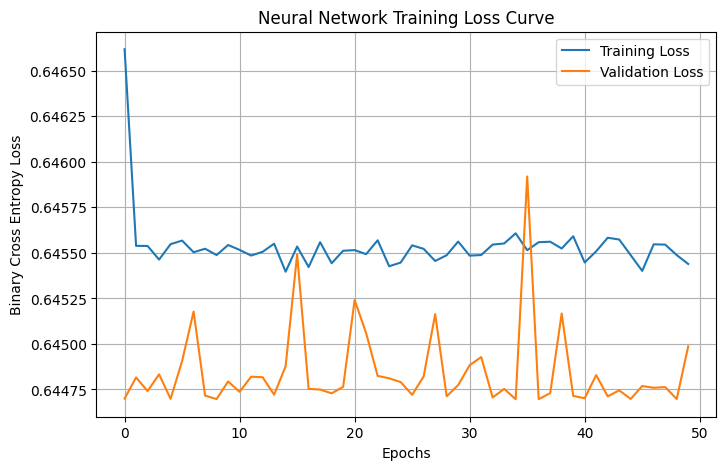

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
import matplotlib.pyplot as plt

# -------------------------------
# 9. Build Neural Network
# -------------------------------
model = Sequential()

# Input layer + first hidden layer
model.add(Dense(32, activation='sigmoid', input_shape=(X_train.shape[1],)))

# Hidden layers (total hidden layers = 9)
for _ in range(8):
    model.add(Dense(32, activation='sigmoid'))

# Output layer
model.add(Dense(1, activation='sigmoid'))

# -------------------------------
# 10. Compile Model
# -------------------------------
optimizer = SGD(learning_rate=0.01)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# -------------------------------
# 11. Train Model
# -------------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# -------------------------------
# 12. Plot Loss Curve
# -------------------------------
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Binary Cross Entropy Loss')
plt.title('Neural Network Training Loss Curve')
plt.legend()
plt.grid(True)
plt.show()


Epoch 1/50


c:\Users\PMLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32000/32000 ━━━━━━━━━━━━━━━━━━━━ 78s 2ms/step - accuracy: 0.6494 - loss: 0.6504 - val_accuracy: 0.6544 - val_loss: 0.6445
Epoch 2/50
32000/32000 ━━━━━━━━━━━━━━━━━━━━ 63s 2ms/step - accuracy: 0.6534 - loss: 0.6459 - val_accuracy: 0.6544 - val_loss: 0.6448
Epoch 3/50
32000/32000 ━━━━━━━━━━━━━━━━━━━━ 62s 2ms/step - accuracy: 0.6534 - loss: 0.6452 - val_accuracy: 0.6544 - val_loss: 0.6444
Epoch 4/50
32000/32000 ━━━━━━━━━━━━━━━━━━━━ 276s 9ms/step - accuracy: 0.6534 - loss: 0.6447 - val_accuracy: 0.6544 - val_loss: 0.6452
Epoch 5/50
32000/32000 ━━━━━━━━━━━━━━━━━━━━ 62s 2ms/step - accuracy: 0.6534 - loss: 0.6443 - val_accuracy: 0.6544 - val_loss: 0.6444
Epoch 6/50
32000/32000 ━━━━━━━━━━━━━━━━━━━━ 82s 2ms/step - accuracy: 0.6534 - loss: 0.6440 - val_accuracy: 0.6544 - val_loss: 0.6443
Epoch 7/50
32000/32000 ━━━━━━━━━━━━━━━━━━━━ 252s 8ms/step - accuracy: 0.6534 - loss: 0.6438 - val_accuracy: 0.6544 - val_loss: 0.6450
Epoch 8/50
32000/32000 ━━━━━━━━━━━━━━━━━━━━ 41s 1ms/step - accuracy: 0.6534 - 

c:\Users\PMLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5274 - loss: 0.6949 - val_accuracy: 0.5312 - val_loss: 0.6940
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.5288 - loss: 0.6945 - val_accuracy: 0.5326 - val_loss: 0.6936
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.5298 - loss: 0.6941 - val_accuracy: 0.5343 - val_loss: 0.6932
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.5312 - loss: 0.6937 - val_accuracy: 0.5354 - val_loss: 0.6928
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.5326 - loss: 0.6934 - val_accuracy: 0.5369 - val_loss: 0.6925
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.5337 - loss: 0.6930 - val_accuracy: 0.5386 - val_loss: 0.6921
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.5347 - loss: 0.6926 - val_accuracy: 0.5404 - val_loss: 0.6917
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.5358 - loss: 0.6923 - val_accuracy: 0.5428 - val_loss: 0.

c:\Users\PMLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6286 - loss: 0.6615 - val_accuracy: 0.6538 - val_loss: 0.6501
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6532 - loss: 0.6512 - val_accuracy: 0.6541 - val_loss: 0.6490
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6532 - loss: 0.6501 - val_accuracy: 0.6539 - val_loss: 0.6483
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6533 - loss: 0.6492 - val_accuracy: 0.6541 - val_loss: 0.6479
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6533 - loss: 0.6486 - val_accuracy: 0.6541 - val_loss: 0.6475
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6533 - loss: 0.6481 - val_accuracy: 0.6544 - val_loss: 0.6472
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6534 - loss: 0.6477 - val_accuracy: 0.6544 - val_loss: 0.6469
Epoch 8/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6534 - loss: 0.6474 - val_accurac

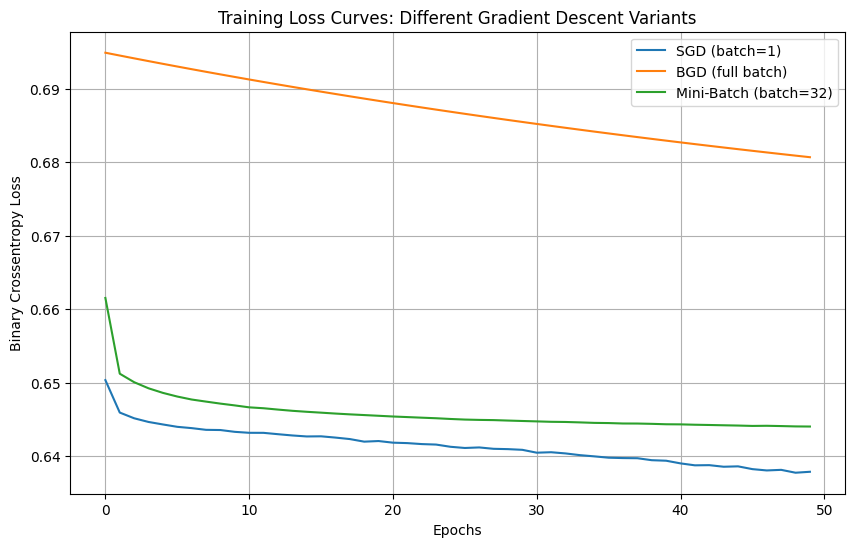

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
import matplotlib.pyplot as plt

# -------------------------------
# Helper function to build the model
# -------------------------------
def build_model(input_dim):
    model = Sequential()
    model.add(Dense(32, activation='relu', input_shape=(input_dim,)))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))  # output layer
    return model

# -------------------------------
# Settings
# -------------------------------
input_dim = X_train.shape[1]
epochs = 50
learning_rate = 0.001

# -------------------------------
# 1️⃣ Stochastic Gradient Descent (batch_size=1)
# -------------------------------
sgd_model = build_model(input_dim)
sgd_model.compile(
    optimizer=SGD(learning_rate=learning_rate),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history_sgd = sgd_model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=1,  # SGD
    validation_split=0.2,
    verbose=1
)

# -------------------------------
# 2️⃣ Batch Gradient Descent (batch_size = full dataset)
# -------------------------------
bgd_model = build_model(input_dim)
bgd_model.compile(
    optimizer=SGD(learning_rate=learning_rate),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history_bgd = bgd_model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=len(X_train),  # full batch
    validation_split=0.2,
    verbose=1
)

# -------------------------------
# 3️⃣ Mini-Batch Gradient Descent (batch_size=32)
# -------------------------------
mbgd_model = build_model(input_dim)
mbgd_model.compile(
    optimizer=SGD(learning_rate=learning_rate),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history_mbgd = mbgd_model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=32,  # mini-batch
    validation_split=0.2,
    verbose=1
)

# -------------------------------
# Plot Loss Curves for Comparison
# -------------------------------
plt.figure(figsize=(10,6))
plt.plot(history_sgd.history['loss'], label='SGD (batch=1)')
plt.plot(history_bgd.history['loss'], label='BGD (full batch)')
plt.plot(history_mbgd.history['loss'], label='Mini-Batch (batch=32)')
plt.xlabel('Epochs')
plt.ylabel('Binary Crossentropy Loss')
plt.title('Training Loss Curves: Different Gradient Descent Variants')
plt.legend()
plt.grid(True)
plt.show()



Training model with sigmoid activation...
Epoch 1/50


c:\Users\PMLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6487 - loss: 0.6484 - val_accuracy: 0.6544 - val_loss: 0.6471
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6534 - loss: 0.6458 - val_accuracy: 0.6544 - val_loss: 0.6452
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6534 - loss: 0.6451 - val_accuracy: 0.6544 - val_loss: 0.6442
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6534 - loss: 0.6448 - val_accuracy: 0.6544 - val_loss: 0.6439
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6534 - loss: 0.6446 - val_accuracy: 0.6544 - val_loss: 0.6452
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6534 - loss: 0.6447 - val_accuracy: 0.6544 - val_loss: 0.6445
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6534 - loss: 0.6443 - val_accuracy: 0.6544 - val_loss: 0.6463
Epoch 8/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6534 - loss: 0.6445 - val_accurac

c:\Users\PMLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6523 - loss: 0.6479 - val_accuracy: 0.6544 - val_loss: 0.6484
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6534 - loss: 0.6464 - val_accuracy: 0.6544 - val_loss: 0.6456
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6533 - loss: 0.6456 - val_accuracy: 0.6544 - val_loss: 0.6445
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6534 - loss: 0.6450 - val_accuracy: 0.6544 - val_loss: 0.6457
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6534 - loss: 0.6449 - val_accuracy: 0.6544 - val_loss: 0.6451
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6534 - loss: 0.6446 - val_accuracy: 0.6544 - val_loss: 0.6476
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6534 - loss: 0.6446 - val_accuracy: 0.6544 - val_loss: 0.6467
Epoch 8/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6533 - loss: 0.6440 - val_accurac

c:\Users\PMLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6528 - loss: 0.6478 - val_accuracy: 0.6544 - val_loss: 0.6455
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6534 - loss: 0.6455 - val_accuracy: 0.6544 - val_loss: 0.6441
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6534 - loss: 0.6442 - val_accuracy: 0.6545 - val_loss: 0.6452
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6534 - loss: 0.6435 - val_accuracy: 0.6544 - val_loss: 0.6479
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6534 - loss: 0.6429 - val_accuracy: 0.6544 - val_loss: 0.6447
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6532 - loss: 0.6425 - val_accuracy: 0.6544 - val_loss: 0.6443
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6534 - loss: 0.6418 - val_accuracy: 0.6544 - val_loss: 0.6453
Epoch 8/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6533 - loss: 0.6412 - val_accurac

c:\Users\PMLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\PMLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6532 - loss: 0.6478 - val_accuracy: 0.6544 - val_loss: 0.6456
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6534 - loss: 0.6448 - val_accuracy: 0.6544 - val_loss: 0.6454
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6534 - loss: 0.6441 - val_accuracy: 0.6544 - val_loss: 0.6458
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6534 - loss: 0.6437 - val_accuracy: 0.6544 - val_loss: 0.6466
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6534 - loss: 0.6431 - val_accuracy: 0.6544 - val_loss: 0.6457
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6534 - loss: 0.6427 - val_accuracy: 0.6544 - val_loss: 0.6467
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6534 - loss: 0.6424 - val_accuracy: 0.6544 - val_loss: 0.6460
Epoch 8/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6533 - loss: 0.6418 - val_accurac

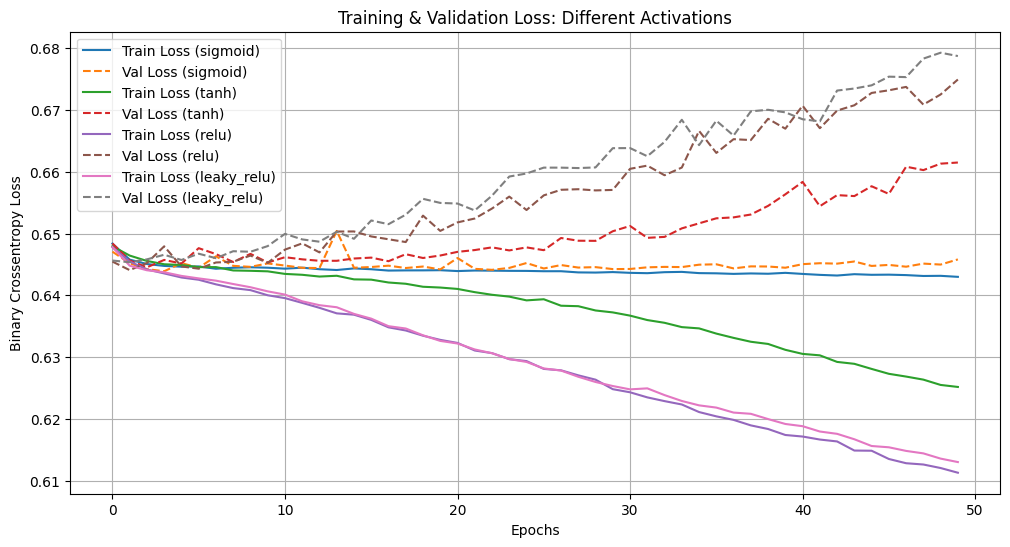

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# -------------------------------
# Settings
# -------------------------------
input_dim = X_train.shape[1]
epochs = 50
batch_size = 32
learning_rate = 0.001
activations = ['sigmoid', 'tanh', 'relu', 'leaky_relu']

# -------------------------------
# Helper function to build models
# -------------------------------
def build_model(input_dim, activation):
    model = Sequential()
    
    # Hidden layers
    if activation == 'leaky_relu':
        model.add(Dense(32, input_shape=(input_dim,)))
        model.add(LeakyReLU(alpha=0.01))
        model.add(Dense(32))
        model.add(LeakyReLU(alpha=0.01))
        model.add(Dense(32))
        model.add(LeakyReLU(alpha=0.01))
    else:
        model.add(Dense(32, activation=activation, input_shape=(input_dim,)))
        model.add(Dense(32, activation=activation))
        model.add(Dense(32, activation=activation))
    
    # Output layer
    model.add(Dense(1, activation='sigmoid'))
    return model

# -------------------------------
# Train models with different activations
# -------------------------------
histories = {}

for act in activations:
    print(f"\nTraining model with {act} activation...")
    model = build_model(input_dim, act)
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=1
    )
    histories[act] = history

# -------------------------------
# Plot Loss Curves for Comparison
# -------------------------------
plt.figure(figsize=(12,6))
for act, history in histories.items():
    plt.plot(history.history['loss'], label=f'Train Loss ({act})')
    plt.plot(history.history['val_loss'], '--', label=f'Val Loss ({act})')
plt.xlabel('Epochs')
plt.ylabel('Binary Crossentropy Loss')
plt.title('Training & Validation Loss: Different Activations')
plt.legend()
plt.grid(True)
plt.show()


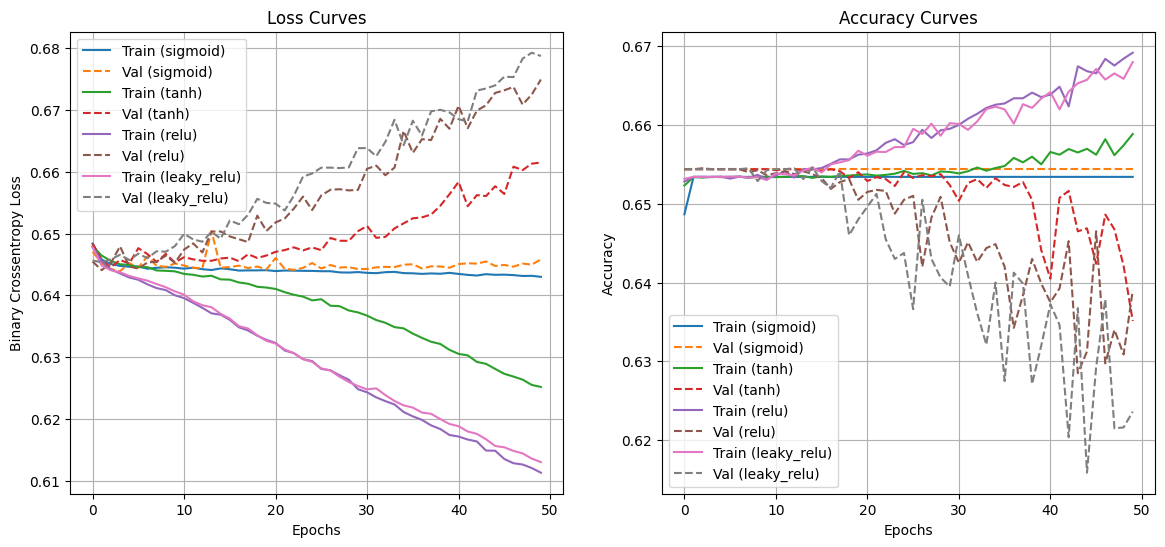

In [5]:
plt.figure(figsize=(14,6))

# Training & Validation Loss
plt.subplot(1,2,1)
for act, history in histories.items():
    plt.plot(history.history['loss'], label=f'Train ({act})')
    plt.plot(history.history['val_loss'], '--', label=f'Val ({act})')
plt.title("Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Binary Crossentropy Loss")
plt.legend()
plt.grid(True)

# Training & Validation Accuracy
plt.subplot(1,2,2)
for act, history in histories.items():
    plt.plot(history.history['accuracy'], label=f'Train ({act})')
    plt.plot(history.history['val_accuracy'], '--', label=f'Val ({act})')
plt.title("Accuracy Curves")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()


In [6]:
results = {}

for act, history in histories.items():
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    
    results[act] = {
        "Train Loss": final_train_loss,
        "Val Loss": final_val_loss,
        "Train Accuracy": final_train_acc,
        "Val Accuracy": final_val_acc
    }

import pandas as pd
results_df = pd.DataFrame(results).T
results_df


,Train Loss,Val Loss,Train Accuracy,Val Accuracy
sigmoid,0.642991,0.645812,0.653406,0.654375
tanh,0.625174,0.661490,0.658844,0.635125
relu,0.611296,0.674923,0.669156,0.639000
leaky_relu,0.613019,0.678719,0.667969,0.623625
